# ReLU experiment

### Generate N * d data manifold X, with tail exponent alpha_X

### Calculate PP(X), actual alpha_X

### Apply ReLU

### Calculate PP(ReLU(X)), actual alpha_ReLUX

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [9]:
this_N = 1000
this_d = 1000

min_alpha = 0.1
max_alpha = 10.0
scale_factor = max_alpha - min_alpha
num_iterations = 100

generate_weight_matrix = True
uniform_draws = True
use_pareto = True
use_uniform = False
use_cauchy = False
verbose = False

alpha_X_vals = np.zeros(num_iterations)
actual_alpha_X_vals = np.zeros(num_iterations)
actual_alpha_reluX_vals = np.zeros(num_iterations)
pp_dim_X_vals = np.zeros(num_iterations)
pp_dim_reluX_vals = np.zeros(num_iterations)
nu_over_d_X_vals = np.zeros(num_iterations)
nu_over_d_reluX_vals = np.zeros(num_iterations)

for i in range(0, num_iterations):
  this_alpha_X = min_alpha + scale_factor * (i / (num_iterations - 1))**2 #1.5
  results_dict = pp.relu_experiment(this_N, this_d, this_alpha_X, generate_weight_matrix, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose)
  alpha_X_vals[i] = this_alpha_X
  actual_alpha_X_vals[i] = results_dict["actual_alpha_X"]
  actual_alpha_reluX_vals[i] = results_dict["actual_alpha_reluX"]
  pp_dim_X_vals[i] = results_dict["pp_dim_X"]
  pp_dim_reluX_vals[i] = results_dict["pp_dim_reluX"]
  nu_over_d_X_vals[i] = results_dict["nu_over_d_X"]
  nu_over_d_reluX_vals[i] = results_dict["nu_over_d_reluX"]
  print(i, this_alpha_X, results_dict["actual_alpha_X"], results_dict["actual_alpha_reluX"], results_dict["nu_over_d_X"], results_dict["nu_over_d_reluX"])

 ** generate_square_weight_matrix: using GPU **
0 0.1 0.2932446671174798 0.4100072261009492 0.001001989045134662 0.001872627094446028
 ** generate_square_weight_matrix: using GPU **
1 0.10101010101010102 0.29327034403773605 0.41241975946482795 0.001002134519318092 0.0018962450973816088
 ** generate_square_weight_matrix: using GPU **
2 0.10404040404040404 0.29335470955344634 0.4126481689821983 0.0010026126090166207 0.0018984961549181256
 ** generate_square_weight_matrix: using GPU **
3 0.1090909090909091 0.293523766784371 0.4121702218787288 0.0010035711524149613 0.0018937887938856159
 ** generate_square_weight_matrix: using GPU **
4 0.11616161616161617 0.2938272395290447 0.41201248423549697 0.0010052935500818223 0.0018922377181242978
 ** generate_square_weight_matrix: using GPU **
5 0.12525252525252525 0.2943470794064408 0.4137082123477404 0.0010082491310162247 0.0019089774888261808
 ** generate_square_weight_matrix: using GPU **
6 0.13636363636363638 0.29520602157747383 0.4149265763124

KeyboardInterrupt: 

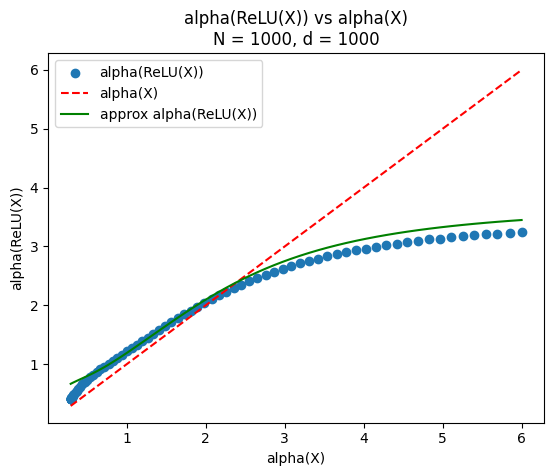

In [52]:
k=78
#this_title = "alpha(ReLU(X)) vs alpha(X)\n"
this_title = "alpha(ReLU(X)) vs alpha(X)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)

nu_over_d_softmax_approx_vals = softmax_approximation(nu_over_d_X_vals[0:k])
num_vals = len(nu_over_d_softmax_approx_vals)
alpha_softmax_approx_vals = np.zeros(num_vals)
for i in range(num_vals):
    this_nu_over_d_softmax_approx = nu_over_d_softmax_approx_vals[i]
    this_alpha_softmax_approx = pp.calculate_alpha_given_nu_over_d_and_d(this_nu_over_d_softmax_approx, this_d)
    alpha_softmax_approx_vals[i] = this_alpha_softmax_approx



plt.scatter(actual_alpha_X_vals[0:k], actual_alpha_reluX_vals[0:k], label="alpha(ReLU(X))")
plt.plot(actual_alpha_X_vals[0:k], actual_alpha_X_vals[0:k], linestyle = "--", label="alpha(X)", color = "red")
plt.plot(actual_alpha_X_vals[0:k], alpha_softmax_approx_vals, color = "green", label = "approx alpha(ReLU(X))")
plt.xlabel("alpha(X)")
plt.ylabel("alpha(ReLU(X))")
plt.legend()
plt.title(this_title)
#plt.savefig('alpha_ReLU_X_vs_alpha_X.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('alpha_ReLU_W_vs_alpha_W_pareto.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('alpha_ReLU_W_vs_alpha_W_Plus_approx_pareto.pdf', dpi=300, bbox_inches='tight')
plt.show()

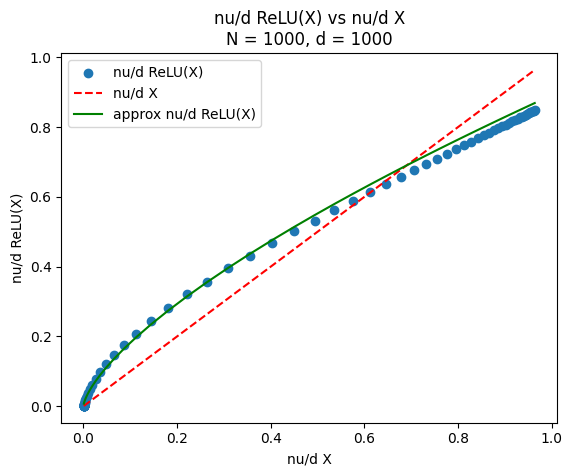

In [56]:
this_title = "nu/d ReLU(X) vs nu/d X\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)

nu_over_d_softmax_approx_vals = softmax_approximation(nu_over_d_X_vals[0:k])

plt.scatter(nu_over_d_X_vals[0:k], nu_over_d_reluX_vals[0:k], label = "nu/d ReLU(X)")
plt.plot(nu_over_d_X_vals[0:k], nu_over_d_X_vals[0:k], linestyle = "--", label = "nu/d X", color = "red")
plt.plot(nu_over_d_X_vals[0:k], nu_over_d_softmax_approx_vals, label = "approx nu/d ReLU(X)", color = "green")
plt.xlabel("nu/d X")
plt.ylabel("nu/d ReLU(X)")
plt.legend()
plt.title(this_title)
#plt.savefig('nu_over_d_ReLU_X_vs_nu_over_d_X.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('nu_over_d_ReLU_W_vs_nu_over_d_W_pareto.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('nu_over_d_ReLU_W_vs_nu_over_d_W_plus_approx_pareto.pdf', dpi=300, bbox_inches='tight')
plt.show()

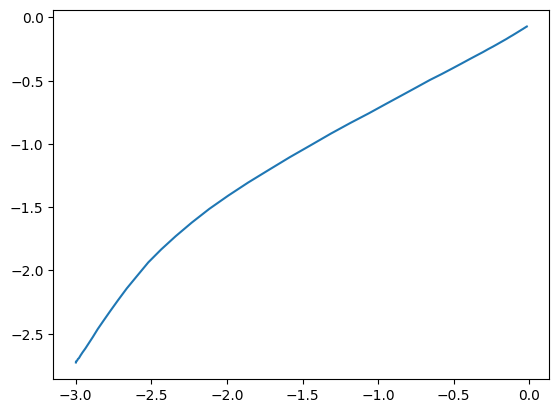

In [24]:
log_nu_over_d_X_vals = this_vec_log10(nu_over_d_X_vals[0:k])
log_nu_over_d_reluX_vals = this_vec_log10(nu_over_d_reluX_vals[0:k])

plt.plot(log_nu_over_d_X_vals, log_nu_over_d_reluX_vals)
plt.show()

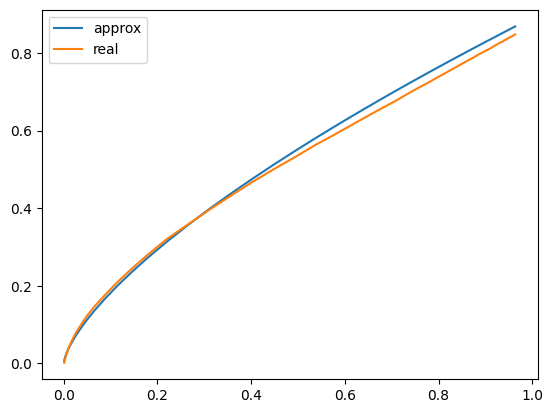

In [42]:
# 0.75, -0.05

this_exponent = 0.69 #0.75
this_log10_constant = -0.05 #-0.049

this_constant = 10**this_log10_constant
approx_vals = ((nu_over_d_X_vals[0:k])**this_exponent ) * this_constant

plt.plot(nu_over_d_X_vals[0:k], approx_vals, label = "approx")
plt.plot(nu_over_d_X_vals[0:k],nu_over_d_reluX_vals[0:k], label = "real")
plt.legend()
plt.show()


In [45]:
def softmax_approximation(these_nu_over_d_vals : np.ndarray) -> np.ndarray:
    this_exponent = 0.69 #0.75
    this_log10_constant = -0.05 #-0.049
    this_constant = 10**this_log10_constant
    approx_vals = (these_nu_over_d_vals**this_exponent) * this_constant
    return approx_vals

In [57]:
print(10**-0.05)

0.8912509381337456


In [21]:
# apply log to an array by vectorisation
def this_log10(x):
  return math.log10(x)

# Apply the function using np.vectorize
this_vec_log10 = np.vectorize(this_log10)

# Experiment n+1 : Fix N and alpha_X, let d increase from 1 to N

In [ ]:
this_N = 1000
step_size = 50
these_iteration_vals = range(1, int(this_N/step_size))
num_iterations = len(these_iteration_vals)

this_alpha_X = 2.0

d_vals = np.zeros(num_iterations)
alpha_X_vals = np.zeros(num_iterations)
actual_alpha_X_vals = np.zeros(num_iterations)
actual_alpha_reluX_vals = np.zeros(num_iterations)
pp_dim_X_vals = np.zeros(num_iterations)
pp_dim_reluX_vals = np.zeros(num_iterations)
nu_over_d_X_vals = np.zeros(num_iterations)
nu_over_d_reluX_vals = np.zeros(num_iterations)

i=0
for xx in these_iteration_vals:
  this_d = xx * step_size
  this_alpha_X = 2.0
  results_dict = pp.relu_experiment(this_N, this_d, this_alpha_X, verbose=False)
  d_vals[i] = this_d
  alpha_X_vals[i] = this_alpha_X
  actual_alpha_X_vals[i] = results_dict["actual_alpha_X"]
  actual_alpha_reluX_vals[i] = results_dict["actual_alpha_reluX"]
  pp_dim_X_vals[i] = results_dict["pp_dim_X"]
  pp_dim_reluX_vals[i] = results_dict["pp_dim_reluX"]
  nu_over_d_X_vals[i] = results_dict["nu_over_d_X"]
  nu_over_d_reluX_vals[i] = results_dict["nu_over_d_reluX"]
  print(i, this_alpha_X, results_dict["actual_alpha_X"], results_dict["actual_alpha_reluX"])
  i += 1

In [ ]:
plt.plot(d_vals, actual_alpha_X_vals)
plt.plot(d_vals, actual_alpha_reluX_vals)
plt.show()

plt.scatter(actual_alpha_X_vals, actual_alpha_reluX_vals)
plt.show()